
# PCA & Clustering on Signals

This notebook builds a feature matrix of rule-based signals (momentum, reversal, volatility, beta, 52-week-high gap) on a universe of assets, then performs **PCA** and **clustering** (K-Means + Hierarchical) to identify groups of instruments with similar signal profiles.


## 1) Setup & imports

In [1]:

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import yfinance as yf
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist


## 2) Download data (monthly)

In [2]:

START = "2005-01-01"
END = None
FREQ = "M"

UNIVERSE = [
    "AAPL","MSFT","AMZN","NVDA","META","GOOGL","GOOG","BRK-B","XOM","JNJ","JPM","V",
    "PG","LLY","AVGO","TSM","UNH","MA","HD","CVX","MRK","ABBV","KO","PEP","BAC",
    "WMT","ADBE","ORCL","COST","ASML","TMO","CSCO","TM","ACN","MCD","DHR","NFLX",
    "LIN","AZN","INTC","NKE","TXN","AMD","PM","UPS","HON","RY","SHEL"
]

prices_d = yf.download(UNIVERSE, start=START, end=END, auto_adjust=True, progress=False)["Close"]
prices_m = prices_d.resample(FREQ).last().dropna(how="all")
prices_m = prices_m.dropna(axis=1, how="any")
rets_m = prices_m.pct_change().fillna(0.0)

print("Monthly price shape:", prices_m.shape)


Monthly price shape: (251, 42)


## 3) Build signals

In [3]:

def momentum_12_1(prices):
    ret = prices.pct_change().fillna(0.0)
    roll = (1 + ret).rolling(12).apply(np.prod, raw=True) - 1.0
    return roll.shift(1)

def reversal_1m(prices):
    r1 = prices.pct_change()
    return -r1

def vol_12m(returns):
    return returns.rolling(12).std()

def beta_36m(returns, bench):
    cov = returns.rolling(36).cov(bench)
    var = bench.rolling(36).var()
    beta = cov.div(var, axis=0)
    return beta

def gap_52w(prices_d, prices_m_like):
    high_52w = prices_d.rolling(252).max()
    monthly = high_52w.resample("M").last().reindex_like(prices_m_like)
    return (prices_m_like / monthly) - 1.0

sig_mom = momentum_12_1(prices_m)
sig_rev = reversal_1m(prices_m)
sig_vol = vol_12m(rets_m)

try:
    spy_d = yf.download("SPY", start=START, end=END, auto_adjust=True, progress=False)["Close"]
    spy_m = spy_d.resample("M").last()
    ret_spy = spy_m.pct_change().fillna(0.0)
    common = rets_m.index.intersection(ret_spy.index)
    beta = beta_36m(rets_m.loc[common], ret_spy.loc[common]).reindex_like(rets_m)
except Exception as e:
    print("SPY not available; beta set to NaN.")
    beta = pd.DataFrame(index=rets_m.index, columns=rets_m.columns, data=np.nan)

gap52 = gap_52w(prices_d, prices_m)


## 4) Assemble feature matrix

In [5]:

analysis_date = prices_m.index[-1]

features = {
    "mom12_1": sig_mom.loc[analysis_date],
    "rev1m": sig_rev.loc[analysis_date],
    "vol12m": sig_vol.loc[analysis_date],
    "beta36m": beta.loc[analysis_date],
    "gap52w": gap52.loc[analysis_date],
}

X = pd.DataFrame({
    "mom12_1": sig_mom.loc[analysis_date],
    "rev1m": sig_rev.loc[analysis_date],
    "vol12m": sig_vol.loc[analysis_date],
    "gap52w": gap52.loc[analysis_date],
}).dropna(how="any")

print("Feature matrix shape:", X.shape)
X.head()


Feature matrix shape: (42, 4)


,mom12_1,rev1m,vol12m,gap52w
Ticker,,,,
AAPL,0.202374,0.002511,0.063653,-0.006296
ACN,-0.264339,0.022191,0.062305,-0.379807
ADBE,-0.288174,0.033675,0.064122,-0.405292
AMD,0.777747,0.047400,0.211394,-0.076987
AMZN,0.310193,-0.017116,0.077647,-0.022047


## 5) Standardize and PCA

Explained variance ratio: [0.46594289 0.39211346 0.11542105 0.02652261]


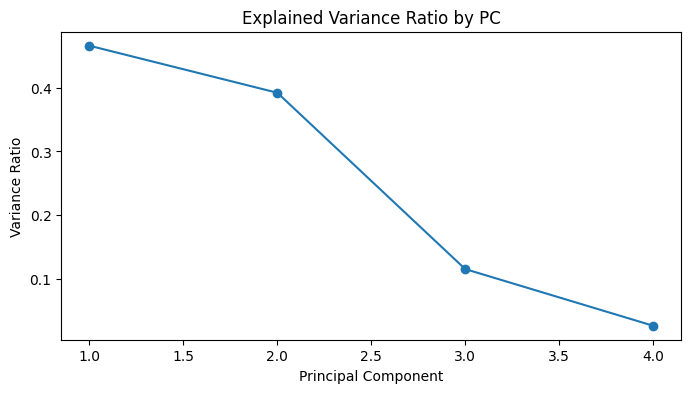

,PC1,PC2,PC3,PC4
mom12_1,0.353528,0.667929,0.247755,-0.606223
rev1m,-0.581696,0.283408,0.714837,0.265175
vol12m,-0.237948,0.675901,-0.596019,0.362353
gap52w,0.692841,0.129258,0.269049,0.656412


In [6]:

scaler = StandardScaler()
X_std = scaler.fit_transform(X.values)

pca = PCA(n_components=min(5, X.shape[1]))
PC = pca.fit_transform(X_std)

explained = pca.explained_variance_ratio_
print("Explained variance ratio:", explained)

plt.figure(figsize=(8,4))
plt.plot(range(1, len(explained)+1), explained, marker="o")
plt.title("Explained Variance Ratio by PC")
plt.xlabel("Principal Component"); plt.ylabel("Variance Ratio")
plt.show()

loadings = pd.DataFrame(pca.components_.T, index=X.columns, columns=[f"PC{i+1}" for i in range(pca.n_components_)])
loadings


## 6) Biplot (PC1 vs PC2)

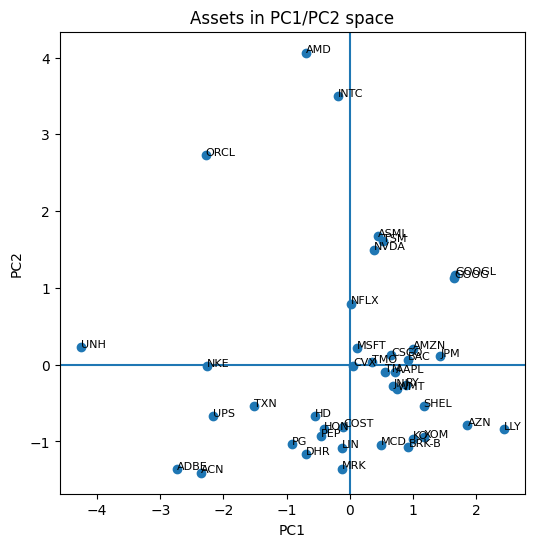

In [7]:

pc_df = pd.DataFrame(PC[:, :2], index=X.index, columns=["PC1","PC2"])

plt.figure(figsize=(6,6))
plt.scatter(pc_df["PC1"], pc_df["PC2"])
for name, row in pc_df.iterrows():
    plt.annotate(name, (row["PC1"], row["PC2"]), fontsize=8)
plt.axhline(0); plt.axvline(0)
plt.title("Assets in PC1/PC2 space")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()


## 7) K-Means clustering

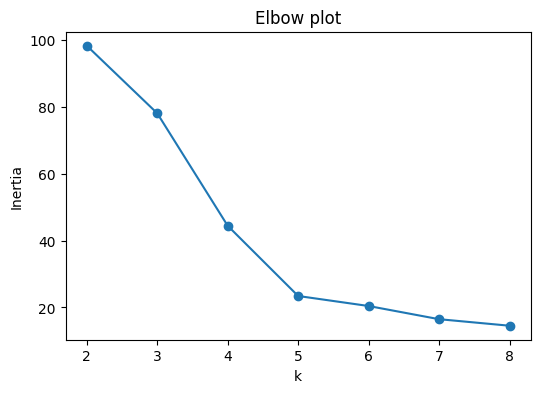

Silhouette score (k=3): 0.296


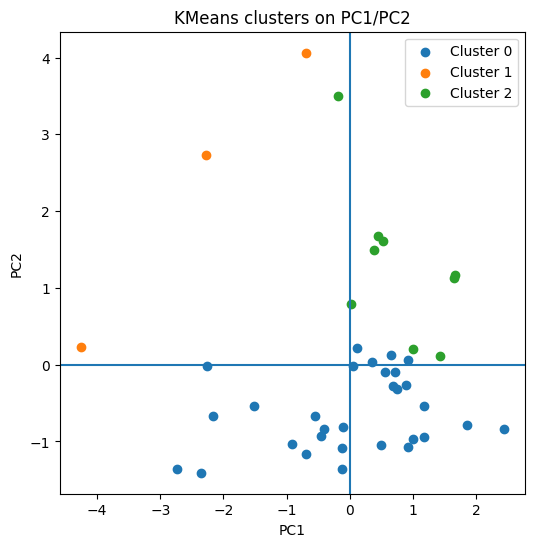

In [8]:

inertias = []
Ks = list(range(2, 9))
for k in Ks:
    km = KMeans(n_clusters=k, n_init="auto", random_state=42)
    km.fit(PC[:, :2])
    inertias.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(Ks, inertias, marker="o")
plt.title("Elbow plot")
plt.xlabel("k"); plt.ylabel("Inertia")
plt.show()

k = 3
km = KMeans(n_clusters=k, n_init="auto", random_state=42)
labels = km.fit_predict(PC[:, :2])

sil = silhouette_score(PC[:, :2], labels)
print("Silhouette score (k=3):", round(sil, 3))

pc_df["cluster_kmeans"] = labels

plt.figure(figsize=(6,6))
for cl in sorted(set(labels)):
    sub = pc_df[pc_df["cluster_kmeans"] == cl]
    plt.scatter(sub["PC1"], sub["PC2"], label=f"Cluster {cl}")
plt.legend()
plt.axhline(0); plt.axvline(0)
plt.title("KMeans clusters on PC1/PC2")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()


## 8) Hierarchical clustering

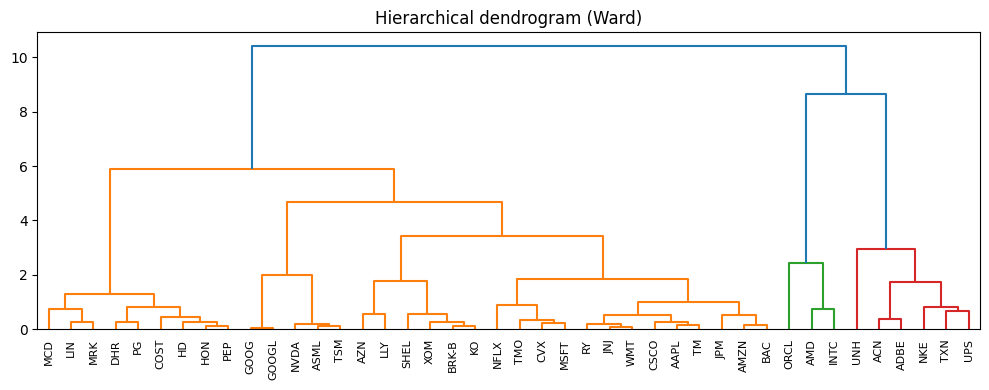

In [9]:

Z = linkage(pdist(PC[:, :2]), method="ward")
plt.figure(figsize=(10, 4))
dendrogram(Z, labels=X.index.tolist(), leaf_rotation=90)
plt.title("Hierarchical dendrogram (Ward)")
plt.tight_layout()
plt.show()

labels_h = fcluster(Z, 3, criterion="maxclust")
pc_df["cluster_hier"] = labels_h


## 9) Export results

In [ ]:

out = pd.concat([X, pc_df], axis=1)
out.to_csv("signals_pca_clusters.csv")
print("Saved: signals_pca_clusters.csv")
out.head()
